In [6]:
from scipy.io import loadmat

# SpikeInterface
from probeinterface import Probe
import spikeinterface as si

import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

"""
    This script preprocesses the Intan data.
    Input:
        .rhs files from Intan
    Output:
        Checkpoint after preprocessing
        Checkpoint after thresholding and calculating MUA peak locations and firing rate
"""

OUT_BASE = OUT_BASE.parent / 'results_threshold' # TODO Temporary


# ---------- Config ----------
# Base paths from config_loading
GEOM_PATH = rcp.resolve_probe_geom_path(PARAMS, REPO_ROOT, session_key=None)

# Intan streams
NPRW_CFG = PARAMS.probes.get("NPRW")
INTAN_STREAM = NPRW_CFG.get("neural_data_stream")
STIM_STREAM = NPRW_CFG.get("stim_data_stream") # "Stim channel"
AUX_STREAM = NPRW_CFG.get("aux_stream")
IR_STREAM = NPRW_CFG.get("ir_stream")
PROCESS_ONLY = PARAMS.preprocessing.get("process_only")  # list of BR indices to process; empty = all, need to map from BR indices to Intan indices using METADATA

# Local reference params, both floats
RADII = (PARAMS.probes.get("NPRW").get("local_radius_inner"), PARAMS.probes.get("NPRW").get("local_radius_outer"))
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")
ARTRMV_MS_BEFORE = float(RATES.get("remove_ms_before", 20.0))
ARTRMV_TAIL_MS   = float(RATES.get("remove_tail_ms_after", 20.0))

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

# 1) Load geometry & mapping
mat_probe = loadmat(Path(GEOM_PATH))
intan_geom = {}
intan_geom["x"] = mat_probe["xcoords"].ravel()
intan_geom["y"] = mat_probe["ycoords"].ravel()
assert intan_geom["x"].size == intan_geom["y"].size, "x/y must have same length"
if "chanMap0ind" in mat_probe: # 0-based device mapping if present
    intan_probe_mapping = intan_geom["device_index_0based"] = mat_probe["chanMap0ind"].ravel()
else:
    raise ValueError("No 0-based chanmap in .mat geometry file.")
if intan_probe_mapping.size != intan_geom["x"].size:
    raise ValueError("device_index_0based length != #contacts")

# Build ProbeInterface Probe
nprw_probe = Probe(ndim=2)
nprw_probe.set_contacts(positions=np.c_[intan_geom["x"], intan_geom["y"]], shapes="square", shape_params={"width": 12.0})
nprw_probe.set_device_channel_indices(intan_probe_mapping) # Apply mapping


In [7]:
INDEX = 1

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
control_dir = CONTROL_PERI_ROOT # / 'target_A'
matches = list(control_dir.glob(f"peristim__NRR_RW*.npz"))
control_npz_path = matches[0]  # or iterate if multiple
control_npz = np.load(control_npz_path, allow_pickle=True)

print(stim_npz)
print(control_npz)

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results_threshold/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122125
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results_threshold/checkpoints/NPRW/rates__NRR_RW026_260324_122125__bin20ms_sigma20ms.npz
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results_threshold/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_122125__BR_002.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results_threshold/checkpoints/PeriStim/control_reaches/peristim__NRR_RW026_260324_121810__BR_001.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...


In [8]:
rates_ch_hz = control_npz['NPRW_rates_hz']
centers_ms = control_npz["NPRW_rel_t"]
edges_ms   = control_npz["NPRW_edges_ms"]

In [ ]:
# z score per trial
mu  = np.nanmean(rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_ch_z = (rates_ch_hz - mu) / sig
psth_z = np.nanmean(rates_ch_z, axis=0)
X = psth_z
t = centers_ms

# Peak value and peak time (argmax) within the search window
X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

# Keep only neurons with a real response; rest go to bottom
z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]

In [11]:
rates_ch_z.shape

(26, 128, 60)

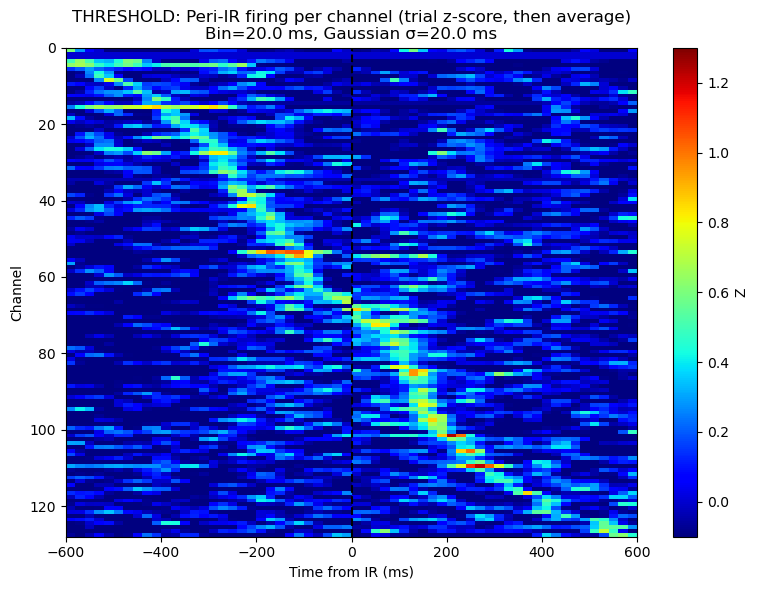

In [ ]:
%matplotlib inline

def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.invert_yaxis()
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"THRESHOLD: Peri-IR firing per channel (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

In [15]:
import dynamax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from jax import vmap
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs
from dynamax.utils.utils import random_rotation

In [16]:
# Parameters for our Poisson demo
state_dim = 2
emission_dim = 10
num_timesteps = 200
num_trials = 3

# Sample random parameters
dynamics_matrix = random_rotation(jr.PRNGKey(0), state_dim, theta=jnp.pi/20)
emission_matrix = jr.normal(jr.PRNGKey(0), shape=(emission_dim, state_dim))
emission_bias = 3.0

# Create a generalized Gaussian SSM with Poisson emissions
params = ParamsGGSSM(
    initial_mean = jnp.zeros(state_dim),
    initial_covariance = jnp.eye(state_dim),
    dynamics_function = lambda z: dynamics_matrix @ z,
    dynamics_covariance = 0.001 * jnp.eye(state_dim),
    emission_mean_function = lambda z: softplus(emission_matrix @ z + emission_bias),
    emission_cov_function = lambda z: jnp.diag(softplus(emission_matrix @ z + emission_bias)),
    emission_dist = lambda mu, Sigma: Poisson(rate=softplus(mu))
)
model = GeneralizedGaussianSSM(state_dim, emission_dim)

# Sample several "trials" worth of data from the model
all_states, all_emissions = \
    vmap(lambda key: model.sample(params, key, num_timesteps=num_timesteps))(
        jr.split(jr.PRNGKey(0), num_trials))

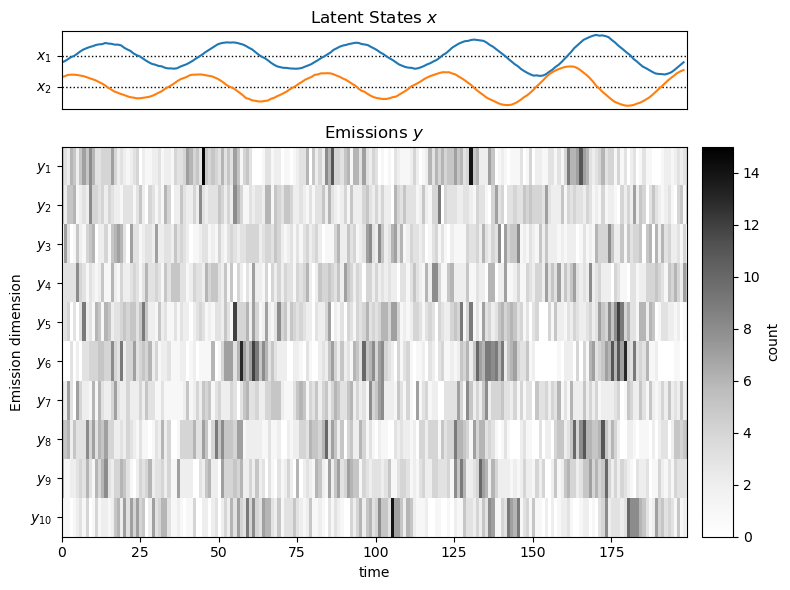

In [17]:
def plot_emissions_poisson(states, data):
    """
    Plot the emissions of a Poisson :DS
    """
    latent_dim = states.shape[-1]
    emissions_dim = data.shape[-1]
    num_timesteps = data.shape[0]

    fig, axs = plt.subplots(2, 2, 
                            height_ratios=(1, emissions_dim / latent_dim), 
                            width_ratios=(20,1), figsize=(8, 6))
    
    # Plot the continuous latent states
    lim = 1.5 * abs(states).max()
    for d in range(latent_dim):
        axs[0,0].axhline(-lim * d, color='k', ls=':', lw=1)
        axs[0,0].plot(states[:, d] - lim * d, "-")
    axs[0,0].set_yticks(-jnp.arange(latent_dim) * lim)
    axs[0,0].set_yticklabels(["$x_{}$".format(d + 1) for d in range(latent_dim)])
    axs[0,0].set_xticks([])
    axs[0,0].set_xlim(0, num_timesteps)
    axs[0,0].set_title(r"Latent States $x$")

    axs[0,1].set_visible(False)

    lim = abs(data).max()
    im = axs[1,0].imshow(data.T, aspect="auto", interpolation="none", cmap="Greys")
    axs[1,0].set_xlabel("time")
    axs[1,0].set_xlim(0, num_timesteps - 1)
    axs[1,0].set_yticks(jnp.arange(emissions_dim))
    axs[1,0].set_yticklabels([rf"$y_{{ {i+1}}}$" for i in jnp.arange(emissions_dim)])
    axs[1,0].set_ylabel("Emission dimension")
    axs[1,0].set_title(r"Emissions $y$")
    plt.colorbar(im, cax=axs[1,1], label="count")

    plt.tight_layout()
    
plot_emissions_poisson(all_states[0], all_emissions[0])

In [18]:
posts = vmap(lambda emissions: cmgs(params, EKFIntegrals(), emissions))(all_emissions)

Text(0.5, 1.0, 'true and inferred states using CMGS')

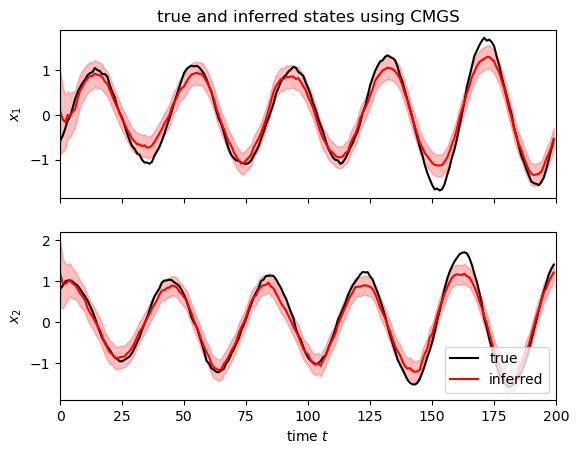

In [19]:
i = 0
fig, axs = plt.subplots(2, 1, sharex=True)
lim = 1.5 * abs(all_states[i]).max()
for d in range(2):
    axs[d].plot(all_states[i, :, d], "-k", label="true")
    axs[d].plot(posts.filtered_means[i, :, d], "-r", label="inferred")
    axs[d].fill_between(
        jnp.arange(num_timesteps),
        posts.filtered_means[i, :, d] - 2 * jnp.sqrt(posts.filtered_covariances[i, :, d, d]),
        posts.filtered_means[i, :, d] + 2 * jnp.sqrt(posts.filtered_covariances[i, :, d, d]),
        color="r",
        alpha=0.25,
    )
    axs[d].set_ylabel(rf"$x_{d+1}$")

axs[-1].set_xlabel(r"time $t$")    
axs[-1].legend(loc="lower right")
axs[-1].set_xlim(0, num_timesteps)
axs[0].set_title("true and inferred states using CMGS")

In [20]:
posts.marginal_loglik

Array([-3862.3262, -3921.869 , -3808.4756], dtype=float32)